In [1]:
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
from langchain.tools import tool
from typing import Dict, Any
from tavily import TavilyClient

tavily_client = TavilyClient()

@tool
def web_search(query: str) -> Dict[str, Any]:

    """Search the web for information"""

    return tavily_client.search(query)

In [ ]:
system_prompt = """

You are a personal chef. The user will give you an image of the the inside of their fridge.

Using the web search tool, search the web for recipes that can be made with the ingredients they have in their fridge.

Return recipe suggestions and eventually the recipe instructions to the user, if requested.

"""

In [ ]:
from langchain.agents import create_agent
from langgraph.checkpoint.memory import InMemorySaver
from IPython.display import display





In [17]:
from PIL import Image
import base64
import io

img = Image.open("IMG_8317.png")
img.thumbnail((1024, 1024))

buf = io.BytesIO()
img.save(buf, format="JPEG", quality=80)

img_b64 = base64.b64encode(buf.getvalue()).decode("utf-8")

In [20]:
from langchain.messages import HumanMessage

agent = create_agent(
    model="gpt-5-nano",
    tools=[web_search],
    system_prompt=system_prompt,
    checkpointer=InMemorySaver()
)

config = {"configurable": {"thread_id": "1"}}

question = HumanMessage(content=[
    {"type": "text", "text": "What can I make with the ingredients in my fridge?"},
    {"type": "image_url", "image_url": {"url": f"data:image/png;base64,{img_b64}"}}
])

response = agent.invoke(
    {"messages": [question]},
    config
)

print(response['messages'][-1].content)

Nice — you’ve got some solid essentials to work with. Based on what’s visible, here are several quick ideas you can make with what I can see (eggs, yogurt/labneh, cream cheese, apricot jam, raspberries, a prepared dish in the tray, etc.). I’ll keep them flexible so you can use what you have beyond these items.

Easy ideas you can make tonight
- Baked eggs with yogurt/labneh
  - Put a little labneh or plain yogurt in a ramekin, crack an egg on top, season with salt/pepper (and herbs if you have them). Bake at 375°F until the egg is set (about 12–15 minutes). Finish with a drizzle of olive oil or hot sauce if you like.

- Cream cheese and apricot jam crostini
  - Toast slices of bread, spread with cream cheese, swirl a bit of apricot jam on top. Optional: chopped nuts or a little pinch of flaky salt.

- Yogurt parfait with raspberries and jam
  - Layer plain yogurt with raspberries and a spoonful of apricot jam or the boxed Mango Raspberry item (if it’s a bar/dessert you want to use as a

{'messages': [HumanMessage(content=[{'type': 'text', 'text': 'What can I make with the ingredients in my fridge?'}, {'type': 'image_url', 'image_url': {'url': ''}}], additional_kwargs={}, response_metadata={}, id='609e9bcb-f26d-48ad-9292-92561f7334a3'),
              AIMessage(content='Nice — you’ve got some solid essentials to work with. Based on what’s visible, here are several quick ideas you can make with what I can see (eggs, yogurt/labneh, cream cheese, apricot jam, raspberries, a prepared dish in the tray, etc.). I’ll keep them flexible so you can use what you have beyond these items.\n\nEasy ideas you can make tonight\n- Baked eggs with yogurt/labneh\n  - Put a little labneh or plain yogurt in a ramekin, crack an egg on top, season with salt/pepper (and herbs if you have them). Bake at 375°F until the egg is set (about 12–15 minutes). Finish with a drizzle of olive oil or hot sauce if you like.\n\n- Cream cheese and apricot jam crostini\n  - Toast slices of bread, spread with c
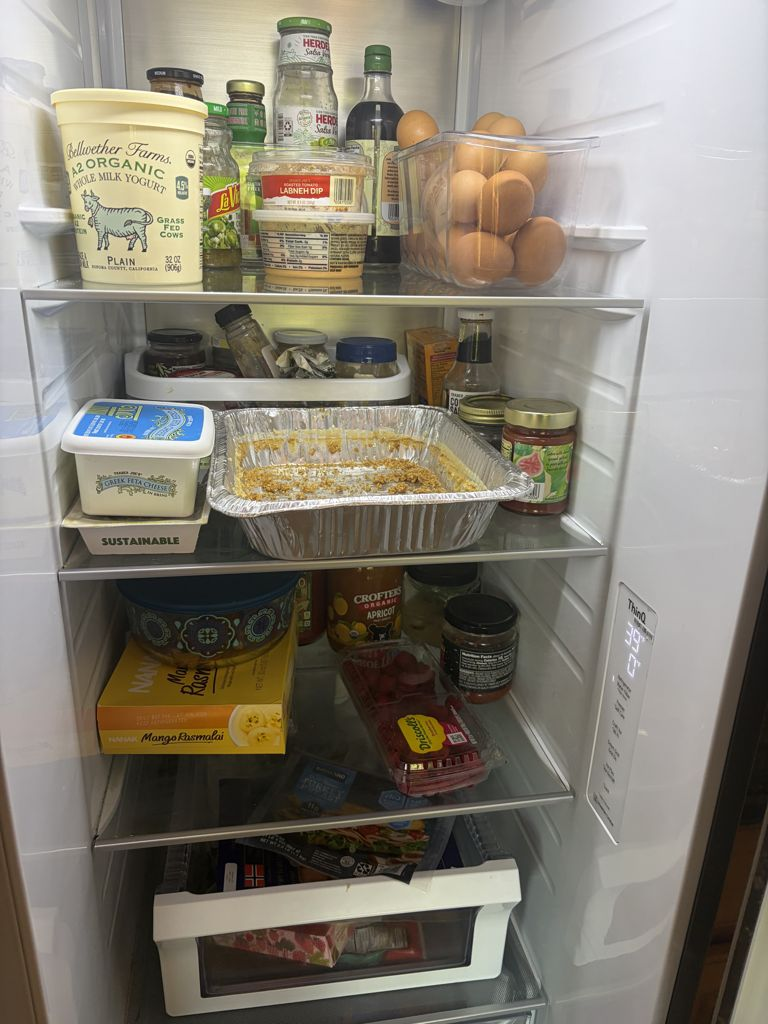

In [21]:
from pprint import pprint

pprint(response)